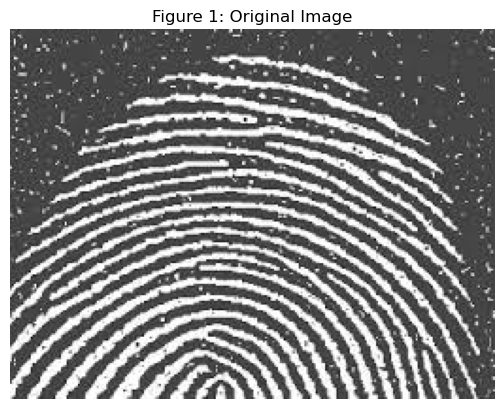

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('data/finger.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Figure 1: Original Image")
plt.show()

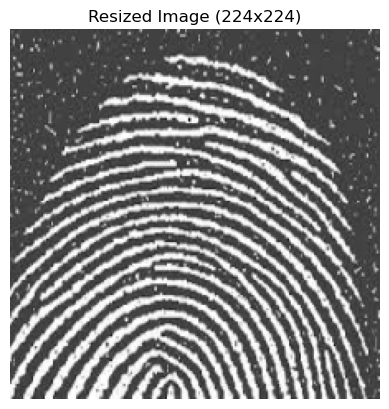

In [2]:
img_resized = cv2.resize(img, (224, 224))

plt.imshow(img_resized, cmap='gray')
plt.axis('off')
plt.title("Resized Image (224x224)")
plt.show()

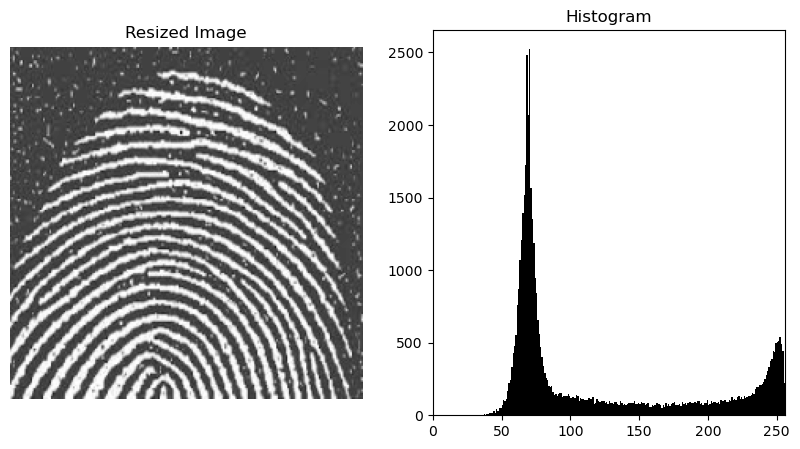

In [3]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap='gray')
plt.axis('off')
plt.title("Resized Image")

plt.subplot(1, 2, 2)
plt.hist(img_resized.ravel(), bins=256, range=[0, 256], color='black')
plt.xlim([0, 256])
plt.title("Histogram")

plt.show()

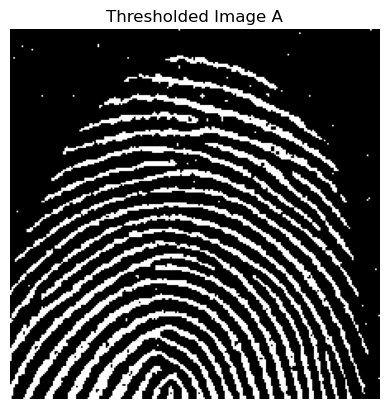

In [9]:
_, A = cv2.threshold(img_resized, 200, 255, cv2.THRESH_BINARY)

plt.imshow(A, cmap='gray')
plt.axis('off')
plt.title("Thresholded Image A")
plt.show()

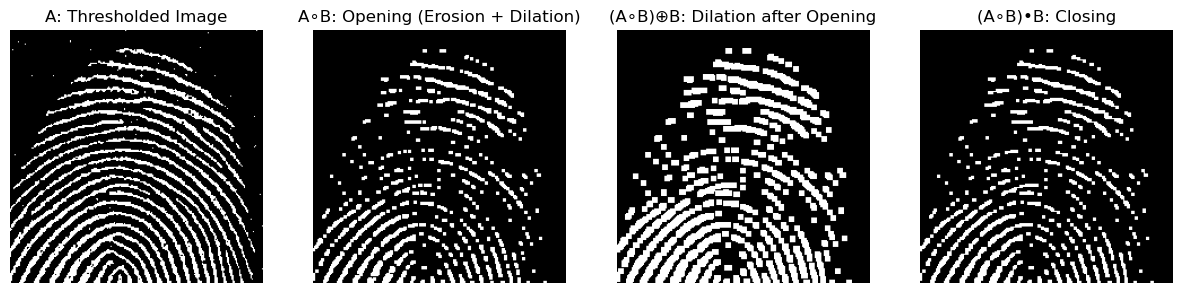

In [10]:
B = np.ones((3, 3), np.uint8)

# erosion followed by dilation
A_open = cv2.morphologyEx(A, cv2.MORPH_OPEN, B)

# dilation of the opened image
A_open_dilate = cv2.dilate(A_open, B)

# closing operation
A_open_close = cv2.morphologyEx(A_open, cv2.MORPH_CLOSE, B)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(A, cmap='gray')
axes[0].set_title("A: Thresholded Image")
axes[0].axis('off')

axes[1].imshow(A_open, cmap='gray')
axes[1].set_title("A∘B: Opening (Erosion + Dilation)")
axes[1].axis('off')

axes[2].imshow(A_open_dilate, cmap='gray')
axes[2].set_title("(A∘B)⊕B: Dilation after Opening")
axes[2].axis('off')

axes[3].imshow(A_open_close, cmap='gray')
axes[3].set_title("(A∘B)•B: Closing")
axes[3].axis('off')

plt.show()

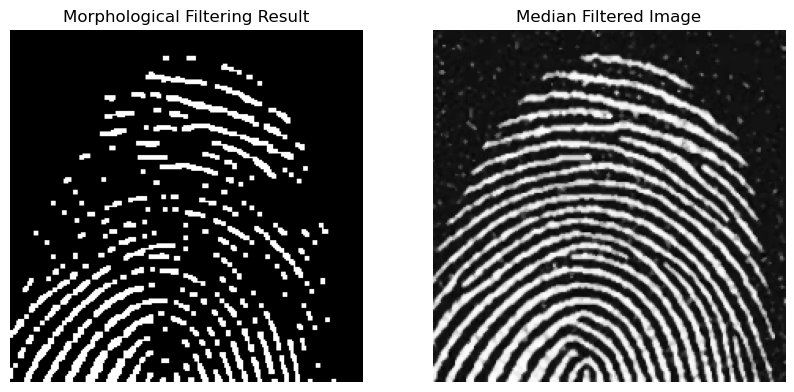

In [11]:
median_filtered = cv2.medianBlur(img_resized, 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(A_open_close, cmap='gray')
axes[0].set_title("Morphological Filtering Result")
axes[0].axis('off')

axes[1].imshow(median_filtered, cmap='gray')
axes[1].set_title("Median Filtered Image")
axes[1].axis('off')

plt.show()